# Assignment 6: Neural Network Showdown — Solution

## Setup

In [1]:
%pip install -q -r requirements.txt

# GPU acceleration (platform-specific)
import platform
if platform.system() == "Darwin" and platform.machine() == "arm64":
    %pip install -q tensorflow-metal

%reset -f

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import numpy as np
import pandas as pd

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

from tensorflow import keras
from keras import Sequential
from keras.layers import (
    Dense, Flatten, Dropout, Conv2D, MaxPooling2D, LSTM, Input
)
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix

from helpers import (
    load_cifar10, load_ecg5000,
    plot_training_history, plot_confusion_matrix,
    plot_sample_images, plot_ecg_traces, plot_predictions,
    CIFAR10_CLASSES, ECG_CLASSES,
)

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete!")

No GPU detected — using CPU
Setup complete!


---

## Part 1: Dense Baseline on CIFAR-10

In [3]:
print("Part 1: Dense Baseline on CIFAR-10")
print("-" * 40)

X_train, y_train, X_test, y_test = load_cifar10()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Part 1: Dense Baseline on CIFAR-10
----------------------------------------


/home/christopher/projects/datasci_223/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


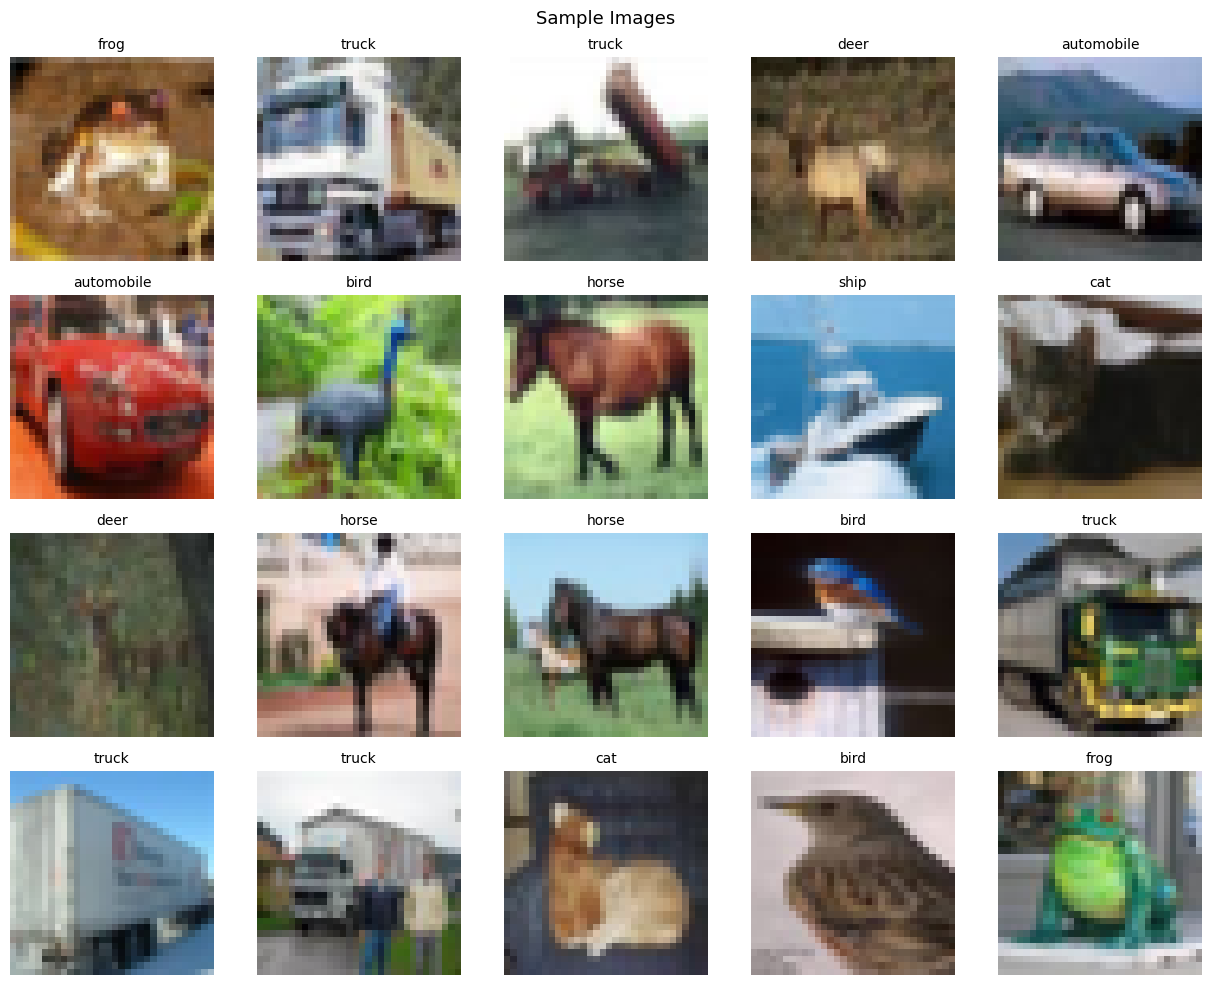

In [4]:
plot_sample_images(X_train, y_train, CIFAR10_CLASSES)

In [5]:
model_dense = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax"),
])

In [6]:
model_dense.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_dense = model_dense.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2319 - loss: 2.0741 - val_accuracy: 0.3272 - val_loss: 1.8717
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2918 - loss: 1.9299 - val_accuracy: 0.3462 - val_loss: 1.8375
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3094 - loss: 1.8813 - val_accuracy: 0.3570 - val_loss: 1.8065
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3294 - loss: 1.8404 - val_accuracy: 0.3770 - val_loss: 1.7607
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3323 - loss: 1.8301 - val_accuracy: 0.3770 - val_loss: 1.7507
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3429 - loss: 1.8074 - val_accuracy: 0.3898 - val_loss: 1.7369
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3442 - loss: 1.7979 - val_accuracy: 0.3710 - val_loss: 1.7655
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3504 - loss: 1.7846 - val_accu

In [8]:
test_loss, test_acc = model_dense.evaluate(X_test, y_test, verbose=0)

y_pred = np.argmax(model_dense.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)

In [9]:
results = {
    "accuracy": float(test_acc),
    "confusion_matrix": cm.tolist(),
}
with open(os.path.join(OUTPUT_DIR, "part1_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"Dense accuracy: {test_acc:.4f}")
print("Saved output/part1_results.json")

Dense accuracy: 0.4274
Saved output/part1_results.json


---

## Part 2: CNN on CIFAR-10

In [10]:
print("\nPart 2: CNN on CIFAR-10")
print("-" * 40)


Part 2: CNN on CIFAR-10
----------------------------------------


In [11]:
model_cnn = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])

In [12]:
model_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [13]:
callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    ),
    ModelCheckpoint(
        "output/best_cnn.keras",
        save_best_only=True,
        monitor="val_accuracy",
    ),
]

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4226 - loss: 1.5920 - val_accuracy: 0.5180 - val_loss: 1.3377
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5419 - loss: 1.2850 - val_accuracy: 0.5938 - val_loss: 1.1598
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5916 - loss: 1.1599 - val_accuracy: 0.6404 - val_loss: 1.0450
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6194 - loss: 1.0851 - val_accuracy: 0.6586 - val_loss: 0.9948
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6370 - loss: 1.0304 - val_accuracy: 0.6756 - val_loss: 0.9391
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6551 - loss: 0.9865 - val_accuracy: 0.6884 - val_loss: 0.9099
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6664 - loss: 0.9510 - val_accuracy: 0.6978 - val_loss: 0.8817
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6799 - loss: 0.9113 - 

In [14]:
plot_training_history(
    history_cnn, os.path.join(OUTPUT_DIR, "part2_training_history.png")
)

In [15]:
cnn_loss, cnn_acc = model_cnn.evaluate(X_test, y_test, verbose=0)

y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_true_cnn = np.argmax(y_test, axis=1)
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

In [16]:
results_cnn = {
    "accuracy": float(cnn_acc),
    "confusion_matrix": cm_cnn.tolist(),
}
with open(os.path.join(OUTPUT_DIR, "part2_results.json"), "w") as f:
    json.dump(results_cnn, f, indent=2)

comparison = pd.DataFrame([
    {"model": "Dense", "accuracy": float(test_acc)},
    {"model": "CNN", "accuracy": float(cnn_acc)},
])
comparison.to_csv(os.path.join(OUTPUT_DIR, "part2_comparison.csv"), index=False)

print(f"CNN accuracy:   {cnn_acc:.4f}")
print(f"Dense accuracy: {test_acc:.4f}")
print(f"Improvement:    {cnn_acc - test_acc:+.4f}")
print("Saved output/part2_results.json and output/part2_comparison.csv")

CNN accuracy:   0.7110
Dense accuracy: 0.4274
Improvement:    +0.2836
Saved output/part2_results.json and output/part2_comparison.csv


---

## Part 3: LSTM on ECG5000

In [17]:
print("\nPart 3: LSTM on ECG5000")
print("-" * 40)

X_train_ecg, y_train_ecg, X_test_ecg, y_test_ecg = load_ecg5000()
print(f"Train: {X_train_ecg.shape}, Test: {X_test_ecg.shape}")
print(f"Classes: {list(ECG_CLASSES.values())}")


Part 3: LSTM on ECG5000
----------------------------------------
Train: (4000, 140, 1), Test: (1000, 140, 1)
Classes: ['Normal', 'Supraventricular', 'Premature Ventricular', 'Fusion', 'Unknown']


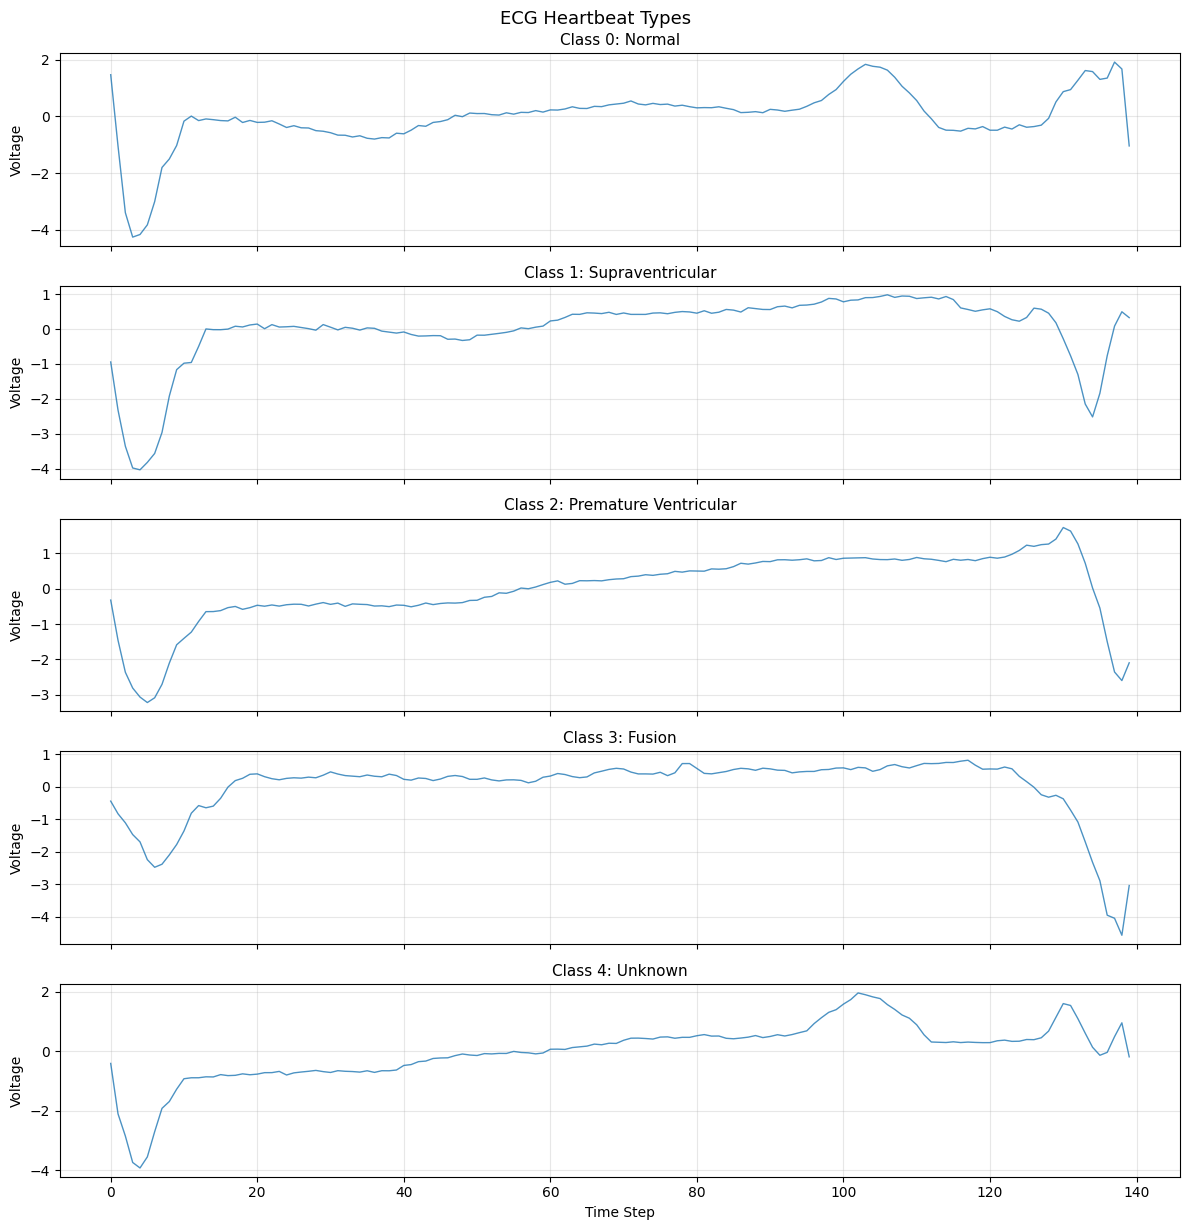

In [18]:
plot_ecg_traces(X_train_ecg, y_train_ecg, ECG_CLASSES)

In [19]:
model_lstm = Sequential([
    Input(shape=(140, 1)),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(5, activation="softmax"),
])

In [20]:
model_lstm.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [21]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_ecg, y_train_ecg,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
)

Epoch 1/30


113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8750 - loss: 0.5818 - val_accuracy: 0.8975 - val_loss: 0.3811
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9267 - loss: 0.2629 - val_accuracy: 0.8950 - val_loss: 0.3424
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9331 - loss: 0.2416 - val_accuracy: 0.9000 - val_loss: 0.3031
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9408 - loss: 0.2168 - val_accuracy: 0.9125 - val_loss: 0.2749
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9419 - loss: 0.2094 - val_accuracy: 0.9125 - val_loss: 0.2885
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9417 - loss: 0.2076 - val_accuracy: 0.9175 - val_loss: 0.2779
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9450 - loss: 0.1998 - val_accuracy: 0.9200 - val_loss: 0.2722
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9461 - loss: 0.1967 - val_accuracy: 0.920

In [22]:
plot_training_history(
    history_lstm, os.path.join(OUTPUT_DIR, "part3_training_history.png")
)

In [23]:
lstm_loss, lstm_acc = model_lstm.evaluate(X_test_ecg, y_test_ecg, verbose=0)

y_pred_ecg = np.argmax(model_lstm.predict(X_test_ecg, verbose=0), axis=1)
y_true_ecg = np.argmax(y_test_ecg, axis=1)
cm_ecg = confusion_matrix(y_true_ecg, y_pred_ecg)

In [24]:
results_ecg = {
    "accuracy": float(lstm_acc),
    "confusion_matrix": cm_ecg.tolist(),
}
with open(os.path.join(OUTPUT_DIR, "part3_results.json"), "w") as f:
    json.dump(results_ecg, f, indent=2)

print(f"LSTM accuracy: {lstm_acc:.4f}")
print("Saved output/part3_results.json")

LSTM accuracy: 0.9290
Saved output/part3_results.json


---

## Validation

In [25]:
print("\nAll parts complete!")
print("Run 'pytest .github/tests/ -v' in your terminal to check your work.")


All parts complete!
Run 'pytest .github/tests/ -v' in your terminal to check your work.
